# Import libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import lightgbm as lgb
import mlflow
import shap
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load data

In [2]:
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
df = pd.read_parquet(ROOT / "data/processed/orders_with_features.parquet")
print(df.shape)
df.head()

(95560, 18)


,order_id,order_purchase_timestamp,split,label,delivery_days,estimated_days,delayed_days,is_late,n_items,n_sellers,total_price,total_freight,avg_weight_g,main_category,freight_ratio,payment_type,max_installments,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,train,0,8,15,-8,0,1,1,29.99,8.72,500.0,utilidades_domesticas,0.290764,credit_card,1.0,SP
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,test,0,13,19,-6,0,1,1,118.70,22.76,400.0,perfumaria,0.191744,boleto,1.0,BA
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,test,0,9,26,-18,0,1,1,159.90,19.22,420.0,automotivo,0.120200,credit_card,3.0,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,train,0,13,26,-13,0,1,1,45.00,27.20,450.0,pet_shop,0.604444,credit_card,1.0,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,train,0,2,12,-10,0,1,1,19.90,8.72,250.0,papelaria,0.438191,credit_card,1.0,SP


# Features

In [3]:
# Define features
cat_cols = ["main_category", "payment_type", "customer_state"]
num_cols = [
    "delivery_days",
    "estimated_days",
    "delayed_days",
    "is_late",
    "n_items",
    "n_sellers",
    "total_price",
    "total_freight",
    "freight_ratio",
    "avg_weight_g",
    "max_installments",
]
features = cat_cols + num_cols

In [4]:
for c in cat_cols:
    df[c] = df[c].astype("category")

# Modeling splits

In [5]:
train, valid, test = (df[df["split"] == s] for s in ["train", "valid", "test"])

X_train, y_train = train[features], train["label"]
X_valid, y_valid = valid[features], valid["label"]
X_test, y_test = test[features], test["label"]

print({s: len(d) for s, d in zip(["train", "valid", "test"], [train, valid, test])})

{'train': 63566, 'valid': 13474, 'test': 18520}


# MLflow setup

In [6]:
# Point MLflow to a local SQLite database file
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Create a new experiment
mlflow.set_experiment("olist-bad-review")

<Experiment: artifact_location='file:c:/Users/mason/OneDrive/olist-return-mlops/notebooks/mlruns/1', creation_time=1790213681124, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790213681124, lifecycle_stage='active', name='olist-bad-review', tags={}, trace_location=None, workspace='default'>

# Evaluation helper

In [7]:
def evaluate(y_true, p, prefix):
    return {
        f"{prefix}_pr_auc": average_precision_score(y_true, p),
        f"{prefix}_roc_auc": roc_auc_score(y_true, p),
    }

In [8]:
def to_str(X):
    return X.astype({c: str for c in cat_cols})

# Logistic regression baseline

In [9]:
pre = make_column_transformer(
    (
        make_pipeline(
            SimpleImputer(strategy="most_frequent"),
            OneHotEncoder(handle_unknown="ignore", min_frequency=50),
        ),
        cat_cols,
    ),
    (make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_cols),
)

logreg = make_pipeline(pre, LogisticRegression(max_iter=1000, class_weight="balanced"))

with mlflow.start_run(run_name="logreg_baseline"):
    logreg.fit(to_str(X_train), y_train)
    p_valid_lr = logreg.predict_proba(to_str(X_valid))[:, 1]
    metrics = evaluate(y_valid, p_valid_lr, "valid")
    mlflow.log_metrics(metrics)
    # mlflow.sklearn.log_model(logreg, 'logreg_baseline')
    # FIX: Explicitly trust the numpy data types inside your transformers
    mlflow.sklearn.log_model(
        sk_model=logreg, name="logreg_baseline", skops_trusted_types=["numpy.dtype"]
    )

print({k: round(v, 4) for k, v in metrics.items()})

{'valid_pr_auc': 0.3574, 'valid_roc_auc': 0.7392}


# LightGBM

In [10]:
params = dict(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    metric="average_precision",
    random_state=42,
    verbose=-1,
)

with mlflow.start_run(run_name="lgbm_v1"):
    model = lgb.LGBMClassifier(**params)

    # FIX 1: Use eval_X and eval_y instead of eval_set
    model.fit(
        X_train,
        y_train,
        eval_X=X_valid,
        eval_y=y_valid,
        callbacks=[lgb.early_stopping(100, verbose=False)],
    )
    p_valid_lgbm = model.predict_proba(X_valid)[:, 1]
    metrics = evaluate(y_valid, p_valid_lgbm, "valid")
    mlflow.log_params({**params, "best_iteration": model.best_iteration_})
    mlflow.log_metrics(metrics)

    # FIX 2: Change the first argument from artifact_path (positional) to name=
    mlflow.lightgbm.log_model(lgb_model=model, name="lgbm_v1")

print(
    {k: round(v, 4) for k, v in metrics.items()},
    "best iteration:",
    model.best_iteration_,
)

{'valid_pr_auc': 0.4002, 'valid_roc_auc': 0.7385} best iteration: 47


# Choose decision threshold

In [11]:
pre, rec, thr = precision_recall_curve(y_valid, p_valid_lgbm)
f1 = 2 * (pre * rec) / (pre + rec)
best_idx = np.argmax(f1[:-1])  # Exclude last value to avoid NaN
threshold = thr[best_idx]

print(f"Best threshold: {threshold:.4f}")
print(f"Validation precision: {pre[best_idx]:.4f}")
print(f"Validation recall: {rec[best_idx]:.4f}")
print(f"Validation F1 score: {f1[best_idx]:.4f}")
print(f"Base rate: {y_valid.mean():.4f}")

Best threshold: 0.2175
Validation precision: 0.4879
Validation recall: 0.3856
Validation F1 score: 0.4308
Base rate: 0.1126


# SHAP feature importance

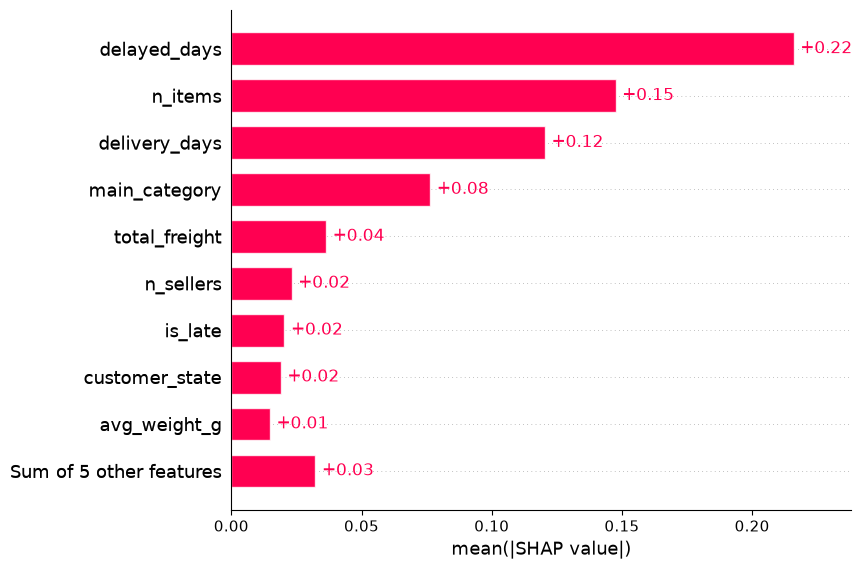

In [12]:
sample = X_valid.sample(2000, random_state=42)

# 1. Use the unified Explainer interface (it automatically detects LightGBM)
explainer = shap.Explainer(model)
shap_values = explainer(sample)

# 2. Use the modern bar plotting tool
shap.plots.bar(shap_values)

# Final test evaluation

In [13]:
p_test_lgbm = model.predict_proba(X_test)[:, 1]
pred_test_lgbm = (p_test_lgbm >= threshold).astype(int)

test_metrics = {
    **evaluate(y_test, p_test_lgbm, "test"),
    "test_precision": precision_score(y_test, pred_test_lgbm),
    "test_recall": recall_score(y_test, pred_test_lgbm),
}

print({k: round(v, 4) for k, v in test_metrics.items()})
print(f"Test base rate: {y_test.mean():.4f}")

{'test_pr_auc': 0.3089, 'test_roc_auc': 0.6838, 'test_precision': 0.4506, 'test_recall': 0.2736}
Test base rate: 0.0973
